# Deep Learning Capstone: Your Own CNN Experiments

In the previous CNN tutorial, you learned the building blocks. Now it's **your turn to experiment!**

This notebook is different: it's not a step-by-step tutorial. Instead, you'll:
1. Get a dataset and baseline CNN
2. Train and evaluate it (quick iteration)
3. **Diagnose** what's wrong (underfitting? overfitting?)
4. **Fix it** by trying different techniques
5. Repeat until you're satisfied!

## Learning Objectives

By the end of this session, you will be able to:
- Set up a complete CNN training pipeline independently
- **Diagnose** model problems from learning curves
- **Apply** targeted fixes (architecture, regularization, augmentation)
- **Iterate** quickly to improve performance
- Make evidence-based decisions about what to try next

<div class="alert alert-block alert-success">
<b>THE LEARNING CYCLE</b>

Modern deep learning is about **fast iteration**:
1. Train quickly (a few epochs)
2. Look at curves (underfit? overfit? good?)
3. Change ONE thing
4. Repeat

Don't try to build the perfect model on the first try!
</div>

In [2]:
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Paths and device
project_root = Path("..").resolve()
data_dir = project_root / "data"
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"✓ Setup complete")
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

✓ Setup complete
✓ Device: mps
✓ PyTorch: 2.10.0


## 1. Load Dataset

For this experiment we will use the CIFAR-100 dataset. It is a variant of the CIFAR-10 dataset we used in the previous tutorial, but with 100 classes instead of 10. This makes it a bit more challenging and realistic.

In [ ]:
# Dataset configuration
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Optional: include data augmentation for training (see below)
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Random shift
    transforms.RandomHorizontalFlip(),     # Flip 50% of time
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_data = datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_transform_aug)
test_data = datasets.CIFAR100(root=data_dir, train=False, download=True, transform=train_transform_aug)


# Get class info
if hasattr(train_data, "classes"):
    class_names = list(train_data.classes)
else:
    class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

num_classes = len(class_names)

print(f"Successfully loaded CIFAR-100!")
print(f"- Training: {len(train_data)} samples")
print(f"- Test: {len(test_data)} samples")
print(f"- Classes: {num_classes}")
print(f"- Example classes: {class_names[:5]}")

100.0%
/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/2026/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Successfully loaded CIFAR-100!
- Training: 50000 samples
- Test: 10000 samples
- Classes: 100
- Example classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']


### Quick Data Exploration

Let's verify the dataset is balanced and visualize some samples.

Class Balance:
- Min samples/class: 500
- Max samples/class: 500


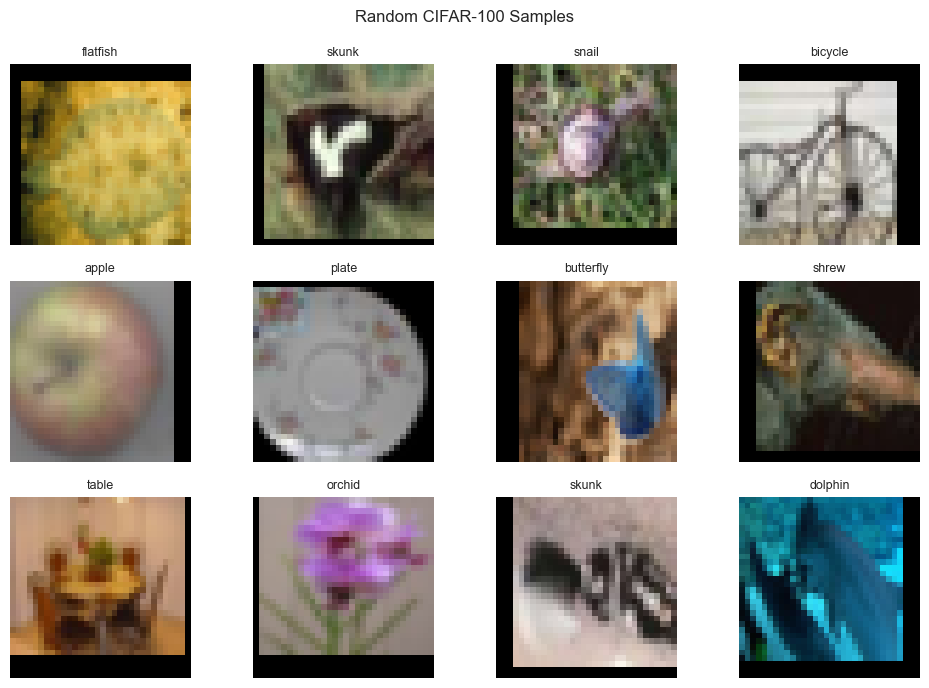

In [4]:
def denormalize(tensor, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return tensor * std_t + mean_t


# Check class balance
targets = torch.tensor(train_data.targets)
counts = torch.bincount(targets, minlength=num_classes)

print(f"Class Balance:")
print(f"- Min samples/class: {int(counts.min())}")
print(f"- Max samples/class: {int(counts.max())}")

# Show samples
indices = torch.randperm(len(train_data))[:12]
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for ax, idx in zip(axes.flatten(), indices):
    image, label = train_data[idx]
    image = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
plt.suptitle(f"Random CIFAR-100 Samples", fontsize=12, y=0.98)
plt.tight_layout()
plt.show()

### Create DataLoaders

Split into train/val and create efficient mini-batch loaders.

In [5]:
# Train/val split
val_size = 5000 if len(train_data) > 5000 else max(10, len(train_data) // 5)
train_size = len(train_data) - val_size

train_ds, val_ds = random_split(
    train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"DataLoaders ready:")
print(f"- Train: {len(train_ds)} samples ({len(train_loader)} batches)")
print(f"- Val: {len(val_ds)} samples ({len(val_loader)} batches)")
print(f"- Test: {len(test_data)} samples ({len(test_loader)} batches)")
print(f"- Batch size: {batch_size}")

# Quick sanity check
xb, yb = next(iter(train_loader))
print(f"\nBatch check:")
print(f"- Input shape: {tuple(xb.shape)} (batch, channels, height, width)")
print(f"- Label range: {int(yb.min())} to {int(yb.max())} (expected: 0 to {num_classes-1})")

DataLoaders ready:
- Train: 45000 samples (352 batches)
- Val: 5000 samples (40 batches)
- Test: 10000 samples (79 batches)
- Batch size: 128

Batch check:
- Input shape: (128, 3, 32, 32) (batch, channels, height, width)
- Label range: 1 to 99 (expected: 0 to 99)


## 2. Training Utilities (Your Toolbox)

These functions are your tools for this session. **You don't need to modify them** - just use them!

Read through once to understand what they do, then focus on experiments.

In [6]:
def accuracy_from_logits(logits, targets):
    """Compute accuracy from raw model outputs"""
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

def evaluate_loader(model, loader, criterion, device):
    """Evaluate model on a dataset"""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            # Move tensors to CPU/GPU as needed
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass and compute loss
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            # Compute batch metrics
            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size

    return total_loss / total_items, total_acc / total_items     # Return average loss and accuracy

def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    """Train model and return history"""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        total_items = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            # Forward pass and compute loss
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Backpropagation and optimization step
            loss.backward()
            optimizer.step()
            
            # Compute batch metrics
            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            running_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size
        
        # Compute epoch metrics
        train_loss = running_loss / total_items
        train_acc = running_acc / total_items
        val_loss, val_acc = evaluate_loader(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.3f} train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")
        
    return history

def plot_history(history):
    """Plot learning curves"""
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot training and validation loss curves
    axes[0].plot(epochs_axis, history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(epochs_axis, history["val_loss"], label="Val", linewidth=2, linestyle="--")
    axes[0].set_title("Loss Over Time", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot training and validation accuracy curves
    axes[1].plot(epochs_axis, history["train_acc"], label="Train", linewidth=2)
    axes[1].plot(epochs_axis, history["val_acc"], label="Val", linewidth=2, linestyle="--")
    axes[1].set_title("Accuracy Over Time", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def show_misclassifications(dataset, model, class_names, device, n=12):
    """Show random misclassified examples"""
    model.eval()
    indices = np.random.permutation(len(dataset))
    wrong = []
    
    with torch.no_grad():
        for idx in indices:
            if len(wrong) >= n:
                break
            image, label = dataset[int(idx)]
            if not isinstance(image, torch.Tensor):
                continue
            logits = model(image.unsqueeze(0).to(device))
            pred = torch.argmax(logits, dim=1).item()
            if int(pred) != int(label):
                wrong.append((image.cpu(), int(label), int(pred)))
    
    if len(wrong) == 0:
        print("✓ No misclassifications found in sample! (Try re-running or increase n)")
        return
    
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    for ax, (image, y_true, y_pred) in zip(axes.flatten(), wrong):
        img = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"True: {class_names[y_true]}\nPred: {class_names[y_pred]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified Examples", fontsize=12, y=0.98)
    plt.tight_layout()
    plt.show()

print("✓ Training utilities loaded")

✓ Training utilities loaded


## 3. Your CNN Architecture

Here's a simple baseline CNN to start with. This is **your playground** - modify it as you experiment!

**Architecture overview:**
```
Input: 32×32×3
  ↓ Conv 32 → ReLU → MaxPool → 16×16×32
  ↓ Conv 64 → ReLU → MaxPool → 8×8×64
  ↓ Conv 128 → ReLU → MaxPool → 4×4×128
  ↓ Flatten → Dense 256 → ReLU → Dropout → Dense num_classes
Output: Class scores
```

<div class="alert alert-block alert-info">
<b>EXPERIMENT IDEAS</b>

**To reduce overfitting:**
- Add BatchNorm2d after Conv layers
- Increase Dropout rate
- Reduce model size (fewer filters)

**To reduce underfitting:**
- Add more Conv blocks
- Increase filter counts (32→64→128→256)
- Remove/reduce Dropout
- Train longer

**Architecture tricks:**
- Try 3×3 kernels everywhere (standard)
- Try stride=2 instead of MaxPool
- Try residual connections (advanced)
</div>

In [ ]:
class StudentCNN(nn.Module):
    """Baseline CNN - modify this as you experiment!"""
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            ### INSERT YOUR MODEL ARCHITECTURE HERE  ###
            # Remember the following structure for convolution blocks:
            # Conv2d -> ReLU -> (optional: BatchNorm2d) -> (optional: Dropout) -> (optional: MaxPool2d)
        )
        
        self.classifier = nn.Sequential(
            ### INSERT YOUR CLASSIFIER ARCHITECTURE HERE ###
            # Remember the following structure for classifier blocks:
            # Flatten -> Linear -> ReLU -> (optional: Dropout) -> (optional: additionaly linear layers)
            # The final layer must output `num_classes` units with no activation (raw logits)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Initialize model
model = StudentCNN(num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(model)
print(f"\nModel stats:")
print(f"- Total parameters: {total_params:,}")
print(f"- Device: {device}")

StudentCNN(
  (features): Sequential()
  (classifier): Sequential()
)

Model stats:
- Total parameters: 0
- Device: mps


In [9]:
class StudentCNN(nn.Module):
    """Baseline CNN - modify this as you experiment!"""
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 32×32×3 → 16×16×32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 16×16×32 → 8×8×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 8×8×64 → 4×4×128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 4×4×128 = 2048 features
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Initialize model
model = StudentCNN(num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(model)
print(f"\nModel stats:")
print(f"- Total parameters: {total_params:,}")
print(f"- Device: {device}")

StudentCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropo

## 4. Training and Evaluation

Let's do a **quick training run** (just 10 epochs) to see how the model performs.

**What to watch for:**
- Starting accuracy (should be near random: ~1% for CIFAR-100, ~10% for CIFAR-10)
- Learning happening? (loss decreasing, accuracy increasing)
- Overfitting signs? (train >> val accuracy)
- Underfitting signs? (both train and val accuracy low)


**QUICK ITERATION STRATEGY**

Train for just **5-10 epochs** per experiment:
- See trends quickly
- Try more ideas in less time
- Only train longer once you found something promising

Starting training (10 epochs)...

Epoch 01/10 | train_loss=4.119 train_acc=0.064 | val_loss=3.687 val_acc=0.121
Epoch 02/10 | train_loss=3.680 train_acc=0.116 | val_loss=3.332 val_acc=0.189
Epoch 03/10 | train_loss=3.480 train_acc=0.151 | val_loss=3.205 val_acc=0.220
Epoch 04/10 | train_loss=3.348 train_acc=0.172 | val_loss=3.055 val_acc=0.233
Epoch 05/10 | train_loss=3.248 train_acc=0.189 | val_loss=2.905 val_acc=0.264
Epoch 06/10 | train_loss=3.176 train_acc=0.203 | val_loss=2.913 val_acc=0.270
Epoch 07/10 | train_loss=3.118 train_acc=0.212 | val_loss=2.770 val_acc=0.300
Epoch 08/10 | train_loss=3.064 train_acc=0.220 | val_loss=2.726 val_acc=0.305
Epoch 09/10 | train_loss=3.020 train_acc=0.229 | val_loss=2.730 val_acc=0.310
Epoch 10/10 | train_loss=2.982 train_acc=0.237 | val_loss=2.673 val_acc=0.318

Training complete!


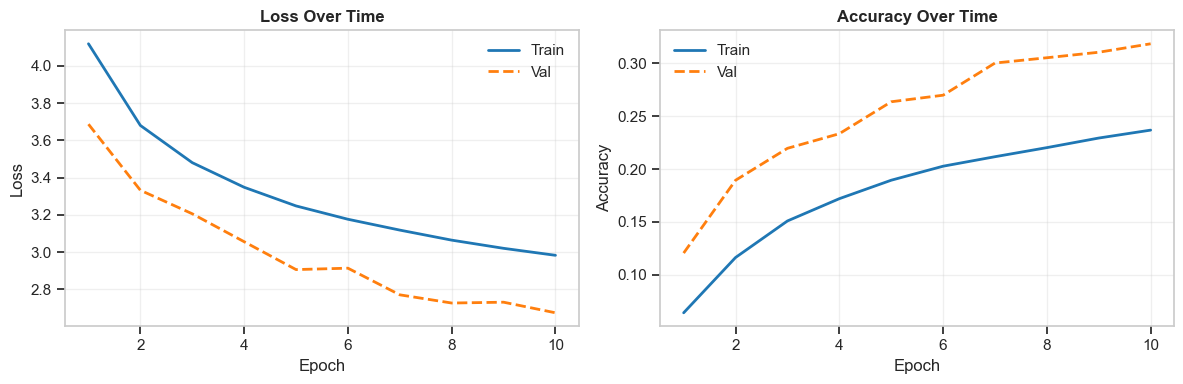

In [10]:
# Training configuration
epochs = 10  # Keep short for fast iteration!
lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f"Starting training ({epochs} epochs)...\n")
history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)

print(f"\nTraining complete!")
plot_history(history)

## 5. Evaluate on Test Set

Now test on held-out data. This is your "honest" performance estimate.

<div class="alert alert-block alert-warning">
This is the final evaluation, only do this once you're happy with your model. Don't peek at the test set during development!
</div>

Test Results:
- Loss: 2.661
- Accuracy: 31.96%
- Gap between test and val: 0.1%


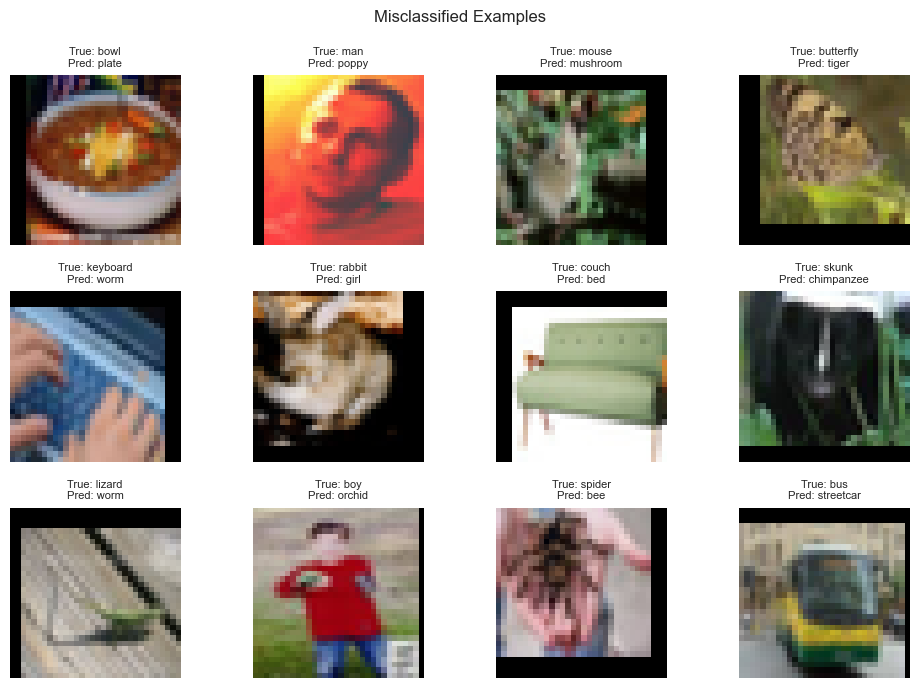

In [11]:
test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)

print(f"Test Results:")
print(f"- Loss: {test_loss:.3f}")
print(f"- Accuracy: {test_acc*100:.2f}%")

# Compare to validation
val_final = history["val_acc"][-1]
diff = abs(test_acc - val_final)
print(f"- Gap between test and val: {diff*100:.1f}%")

# Show some mistakes
show_misclassifications(test_data, model, class_names, device, n=12)

### Confusion Analysis (for CIFAR-10 only)

For CIFAR-100 (100 classes), confusion matrices are too large. We'll just show top confusions.

In [12]:
# Collect predictions
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        # Predict and store results
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(targets.cpu())

# Concatenate all predictions and targets
y_true = torch.cat(all_targets)
y_pred = torch.cat(all_preds)

# Show top confusions
cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
for t, p in zip(y_true, y_pred):
    cm[int(t), int(p)] += 1

# Get off-diagonal (errors only)
off_diag = cm.clone()
off_diag.fill_diagonal_(0)

flat = off_diag.flatten()
top_vals, top_idx = torch.topk(flat, k=min(10, flat.numel()))

print("Top 10 Confusions (True → Predicted):")
print("=" * 60)
for v, idx in zip(top_vals.tolist(), top_idx.tolist()):
    if v == 0:
        break
    i = idx // num_classes
    j = idx % num_classes
    print(f"  {class_names[i]:20s} → {class_names[j]:20s} : {v:3d} times")

Top 10 Confusions (True → Predicted):
  pine_tree            → oak_tree             :  35 times
  maple_tree           → oak_tree             :  34 times
  ray                  → shark                :  29 times
  willow_tree          → oak_tree             :  28 times
  leopard              → tiger                :  27 times
  dolphin              → shark                :  24 times
  raccoon              → wolf                 :  24 times
  pickup_truck         → bus                  :  24 times
  whale                → shark                :  23 times
  possum               → wolf                 :  23 times


---
## 6. Experimental Tools

Now it's time to experiment! You have your baseline model and training pipeline. Now let's try to improve it.

Besides changing your model architecture, learning rate, or other hyperparameters, we provide some tools you can use to improve your model. **Pick ONE at a time** and see what happens!

### Tool 1: Data Augmentation

Data augmentation is the single most effective technique for image classification. By applying random transformations during training, you can make your model more robust against variations in the input data and improve generalization.

In [ ]:
# Data augmentation (training only!)
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Random shift
    transforms.RandomHorizontalFlip(),     # Flip 50% of time
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# To use this:
# 1. Reload dataset with train_transform_aug
# 2. Recreate DataLoaders
# 3. Train a new model

### Tool 2: Stronger Regularization

Try these if you're **overfitting** (train >> val accuracy).

- **Weight decay** (L2 regularization) is a powerful technique to prevent overfitting by adding a penalty to large weights. Try increasing the weight decay parameter in your optimizer.
- **Label smoothing** is another effective regularization technique that softens the target labels, preventing the model from becoming too confident in its predictions. Try applying label smoothing to your loss function.

In [ ]:
# Option A: Weight decay (L2 regularization)
optimizer_wd = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)

# Option B: Label smoothing (softer targets)
criterion_ls = nn.CrossEntropyLoss(label_smoothing=0.1)

### Tool 3: Learning Rate Scheduling

If training plateaus, try reducing learning rate over time. By decreasing the learning rate, you allow the model to make finer adjustments to the weights, which can help it converge to a better solution.

In [ ]:
# Reduce LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

# To use this, you will need to modify the fit() loop.
# After each epoch, call:
# scheduler.step(val_loss)

---
## 7. Your Experiment Log

**Document your experiments here!** Copy/paste this template for each experiment:

```
=== EXPERIMENT N ===
Hypothesis: [What do you think will happen?]
Changes: [What did you change from previous run?]

Results:
- Train acc: X%
- Val acc: X%
- Test acc: X%

Observations: [What happened? Match your hypothesis?]
Next step: [What will you try next?]
```

**Example:**
```
=== EXPERIMENT 1 (Baseline) ===
Hypothesis: Will underfit (model too small for CIFAR-100)
Changes: None (first run)

Results:
- Train acc: 35%
- Val acc: 28%
- Test acc: 27%

Observations: Gap between train/val suggests slight overfitting. But both are low, so also underfitting.
Next step: Try data augmentation first (always good for vision).
```

---
# 📝 START YOUR LOG HERE:



In [ ]:
# ==================================================
# EXPERIMENT: [Give it a name]
# ==================================================
# Hypothesis: [What do you expect?]
# Changes: [What's different?]

# 1. Define model
# model = StudentCNN(num_classes=num_classes).to(device)

# 2. Define training setup
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# epochs = 5

# 3. Train
# history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)
# plot_history(history)

# 4. Evaluate
# test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)
# print(f"Test accuracy: {test_acc*100:.2f}%")

# 5. Analyze mistakes (optional)
# show_misclassifications(test_dataset, model, class_names, device)

# ==================================================
# RESULTS:
# - Train acc: 
# - Val acc:
# - Test acc:
# 
# OBSERVATIONS:
# [What did you learn?]
# ==================================================

## Summary and Reflection

By now you should have run 3-5 experiments. Reflect on what you learned:

1. **What worked best for improving validation accuracy?**
   - Data augmentation? Bigger model? Regularization?

2. **What surprised you?**
   - Did something work better/worse than expected?

3. **How would you continue if you had more time?**
   - More epochs? Different architecture? Better augmentation?

4. **What did you learn about the diagnosis → fix cycle?**
   - Can you quickly identify overfitting vs underfitting?
   - Do you know which tools to reach for?

### Key Takeaways

**Fast iteration** beats perfect planning  
**Learning curves** tell you what to do next  
**Change one thing** at a time to understand impact  
**Data augmentation** almost always helps for vision  
**Experimentation** is how you learn deep learning  

**You're now ready for real-world CNN projects!**